# Hands-on: the three deliverables, proved a second way

**Week 2, Friday. The escalated case, part 5.** You built the three deliverables in Excel. This
notebook reaches the same numbers in pandas, which is Kavya's review: a second way to the same number.
Seven lettered `TODO` markers across six steps; each step ends on checks that tell you whether you
picked right. This is the executed solution.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
import pandas as pd

clean = pd.read_csv(kit.data_dir() / "C2_W02_D05_customer_table_STUDENT.csv")
raw = pd.read_csv(kit.data_dir() / "C2_W02_D05_raw_export_STUDENT.csv")
WAREHOUSE = {"Q1": 100_000_000, "Q2": 98_400_000}   # Monday's warehouse totals, from Week 2 Monday
SEGMENTS = ["Business", "Retail-Core", "Retail-Plus", "Student"]


def crore(n):
    return f"Rs {n / 1e7:.2f} crore"


def lakh(n):
    return f"Rs {n / 1e5:.2f} lakh"


print(len(clean), "customer rows and", len(raw), "export rows loaded")

300 customer rows and 1450 export rows loaded


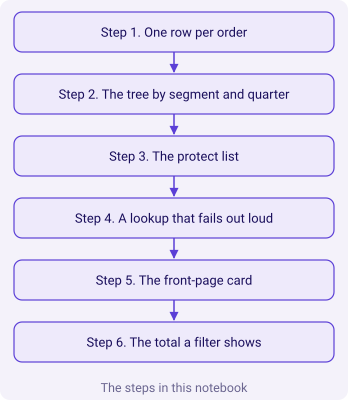

In [2]:
kit.vflow(['Step 1. One row per order', 'Step 2. The tree by segment and quarter', 'Step 3. The protect list', 'Step 4. A lookup that fails out loud', 'Step 5. The front-page card', 'Step 6. The total a filter shows'], title='The steps in this notebook')

## Step 1. One row per order

The raw export has one row per payment. Pick the line that leaves one row per order.

In [3]:
# TODO 1. Which line leaves exactly one row per order?
#   a) orders = raw.drop_duplicates()
#   b) orders = raw.drop_duplicates("customer_id")
#   c) orders = raw.drop_duplicates("order_id")
#   d) orders = raw[raw.paid_amount > 0]
orders = raw.drop_duplicates("order_id")
orders = orders.assign(quarter=pd.to_datetime(orders.order_date).dt.month.map(lambda m: "Q1" if m <= 6 else "Q2"))
print(len(raw), "rows in the export,", len(orders), "rows after this step")

1450 rows in the export, 1000 rows after this step


In [4]:
kit.check("one row per order", len(orders) == orders.order_id.nunique() == 1000, f"{len(orders)} rows")
kit.check("the two quarters reconcile to the warehouse", int(orders.order_amount.sum()) == sum(WAREHOUSE.values()),
          crore(orders.order_amount.sum()))

**Why the other letters fail.** a keeps the 400 instalment orders twice, since their rows differ in paid_amount. b keeps one order per customer and loses 700 orders. d drops the 30 unpaid orders and keeps every repeat.

## Step 2. The tree by segment and quarter

Customers, orders and revenue per segment and quarter, then the two rates.

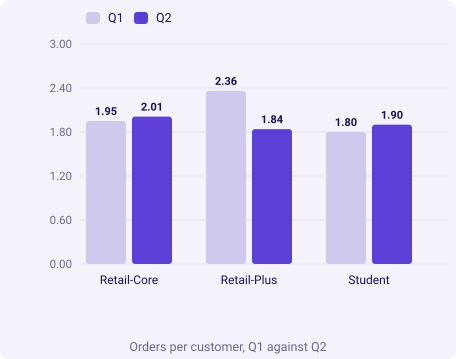

In [5]:
# TODO 2. How are customers counted in each segment and quarter?
#   a) ("customer_id", "count")
#   b) ("customer_id", "nunique")
#   c) ("order_id", "nunique")
#   d) ("customer_id", "size")
tree = orders.groupby(["segment", "quarter"]).agg(customers=("customer_id", "nunique"),
                                                  orders=("order_id", "size"),
                                                  revenue=("order_amount", "sum"))
# TODO 3. Orders per customer is which division?
#   a) tree.customers / tree.orders
#   b) tree.revenue / tree.customers
#   c) tree.orders / tree.customers
#   d) tree.orders / tree.customers.sum()
tree["orders_per_customer"] = tree.orders / tree.customers
tree["revenue_per_order"] = tree.revenue / tree.orders
kit.columns(["Retail-Core", "Retail-Plus", "Student"],
            [(qq, [round(tree.loc[(s, qq), "orders_per_customer"], 2) for s in ["Retail-Core", "Retail-Plus", "Student"]])
             for qq in ["Q1", "Q2"]], fmt=lambda v: f"{v:.2f}", title="Orders per customer, Q1 against Q2")

In [6]:
kit.check("Retail-Plus has 76 customers in Q2", tree.loc[("Retail-Plus", "Q2"), "customers"] == 76,
          f"{tree.loc[('Retail-Plus', 'Q2'), 'customers']}")
kit.check("Retail-Plus orders per customer fall from 2.36 to 1.84",
          round(tree.loc[("Retail-Plus", "Q1"), "orders_per_customer"], 2) == 2.36 and
          round(tree.loc[("Retail-Plus", "Q2"), "orders_per_customer"], 2) == 1.84)

**Why the other letters fail.** TODO 2: a and d count rows, so a customer with three orders counts three times; c counts orders. TODO 3: a inverts the rate; b is revenue per customer; d divides by every customer in every segment and quarter.

## Step 3. The protect list

The fifty Retail-Plus members with the highest revenue across both quarters, from the clean table.

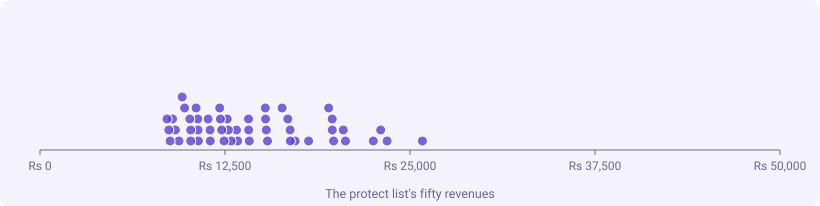

In [7]:
# TODO 4. Which line gives the fifty Retail-Plus members with the highest revenue?
#   a) clean.nlargest(50, "revenue")
#   b) clean[clean.segment == "Retail-Plus"].nsmallest(50, "revenue")
#   c) clean[clean.segment == "Retail-Plus"].head(50)
#   d) clean[clean.segment == "Retail-Plus"].nlargest(50, "revenue")
protect = clean[clean.segment == "Retail-Plus"].nlargest(50, "revenue")
kit.strip(protect.revenue.tolist(), title="The protect list's fifty revenues")

In [8]:
kit.check("fifty members, all Retail-Plus", len(protect) == 50 and set(protect.segment) == {"Retail-Plus"})
kit.check("the cut-off is Rs 8,580", int(protect.revenue.min()) == 8580, kit.rupees(protect.revenue.min()))

**Why the other letters fail.** a ranks every segment together, so 39 Business buyers take most of the fifty places. b keeps the fifty lowest. c keeps the first fifty by id order, which is no ranking at all.

## Step 4. A lookup that fails out loud

The lookup the chief of staff types an id into. It must say so when the id is missing.

In [9]:
by_id = clean.set_index("customer_id")
# TODO 5. Which lookup returns the revenue for an id, or the words "not in the table"?
#   a) lambda m: by_id.revenue.get(m, "not in the table")
#   b) lambda m: by_id.revenue.iloc[by_id.index.searchsorted(m) - 1]
#   c) lambda m: by_id.revenue.iloc[0]
#   d) lambda m: by_id.revenue.asof(m)
lookup = lambda m: by_id.revenue.get(m, "not in the table")
kit.table(["Id", "Answer"], [(m, lookup(m)) for m in ["C-0152", "C-0195"]])

Id,Answer
C-0152,25840
C-0195,not in the table


In [10]:
kit.check("a present id returns its revenue", lookup("C-0152") == 25840)
kit.check("a missing id says so", lookup("C-0195") == "not in the table", str(lookup("C-0195")))

**Why the other letters fail.** b and d are approximate matches: each returns the neighbour below a missing id, which is VLOOKUP with its fourth argument left out. c returns the first member for every id.

## Step 5. The front-page card

Q2 revenue with its comparison, measured on the earlier quarter.

In [11]:
q1 = int(orders.loc[orders.quarter == "Q1", "order_amount"].sum())
q2 = int(orders.loc[orders.quarter == "Q2", "order_amount"].sum())
# TODO 6. Which is the change from Q1 to Q2?
#   a) (q2 - q1) / q2
#   b) (q2 - q1) / q1
#   c) (q1 - q2) / (q1 + q2)
#   d) q2 / q1
change = (q2 - q1) / q1
card = (f"Q2, July to September 2026: {crore(q2)}, {'down' if change < 0 else 'up'} {abs(change):.1%} "
        f"on Q1, April to June 2026 ({crore(q1)})")
print(card)

Q2, July to September 2026: Rs 9.84 crore, down 1.6% on Q1, April to June 2026 (Rs 10.00 crore)


In [12]:
kit.check("the change is minus 1.6 percent", round(change * 100, 1) == -1.6, f"{change:.2%}")
kit.check("the card names both periods", "July to September" in card and "April to June" in card)

**Why the other letters fail.** a divides by the current quarter and reads minus 1.63 percent; on Retail-Plus the same slip reads 41.7 against 29.4. c is a share of the two quarters together. d is a ratio, 0.984, which a card would print as 98 percent.

## Step 6. The total a filter shows

The chief of staff filters the list to Mumbai. What does the foot say?

In [13]:
visible = protect.city == "Mumbai"
# TODO 7. Which total is what SUBTOTAL(109) shows at the foot of the filtered list?
#   a) protect.revenue.sum()
#   b) protect.loc[visible, "revenue"].sum()
#   c) protect.loc[~visible, "revenue"].sum()
#   d) clean.loc[clean.city == "Mumbai", "revenue"].sum()
foot = protect.loc[visible, "revenue"].sum()
kit.stats([(kit.rupees(foot), "the foot", f"{int(visible.sum())} rows visible")])

In [14]:
kit.check("the foot adds only the eleven Mumbai members", int(foot) == 156790, kit.rupees(foot))
kit.check("the foot is less than the whole list", foot < protect.revenue.sum())

**Why the other letters fail.** a is SUM, which adds the rows the filter hid. c adds exactly the hidden rows. d adds every Mumbai customer in every segment, Business included.

**Post.** Your seven letters in order, as one line, and the three numbers your checks confirmed:
the Q2 revenue, the protect list's cut-off and the Mumbai foot. The key is `cbcdabb`.

In [15]:
kit.check_summary()